# 2D Coulomb Gas Metropolis Notebook

This notebook reorganizes the earlier script into sections and ties the simulation choices to the uploaded papers.

## Literature notes motivating the code

We simulate the **symmetric two-component 2D Coulomb gas** with hard core:
\[
u_{ij}=
\begin{cases}
-\,q_i q_j \, (K/T)\,\ln(r_{ij}/\sigma), & r_{ij}\ge \sigma\\
+\infty, & r_{ij}<\sigma
\end{cases}
\]
with \(q_i=\pm 1\).

This follows the standard hard-core logarithmic Coulomb gas setup discussed in the uploaded papers:

- Orkoulas & Panagiotopoulos (1996): the model is a two-component hard-disk Coulomb gas with
  \(u_{ij} = - q_i q_j D^{-1}\ln(r_{ij}/s)\) for \(r_{ij}>s\), and the KT line starts at \(T^\*=1/4\) at zero density. They also report that at low reduced temperatures the KT line turns into a **first-order dielectric vapor / conducting liquid coexistence line** near a critical point. 

- Caillol & Levesque (1986): at very low densities they find the expected KT transition, while at moderate densities the transition becomes **first order between a dielectric gas and a conductive liquid**. 

- Hansen & Viot (1985): for the symmetric 2D Coulomb gas they emphasize **pair formation** and a “chemical equilibrium” between tightly bound ion pairs and free ions, which is exactly the main structure this notebook tries to visualize. 

- Caillol et al. (1982) is mainly about the **one-component plasma**, but it is useful methodologically because it explains why long-range logarithmic interactions are numerically delicate and why sphere/Ewald approaches are often preferred over the simplest planar local-update simulations. 

## What this notebook is and is not

This notebook is for **visual exploration**:
- snapshots,
- opposite-charge distance histograms,
- close-pair fraction,
- nearest opposite-charge distance.

It is **not** a precision phase-diagram code. It uses:
- fixed particle number,
- local Metropolis moves,
- minimal-image periodic boundaries,
- no Ewald sum,
- and it **ignores the extra** \(T\ln(2\cosh(\cdots))\) term as requested.

So this is good for seeing **pairing vs plasma-like behavior**, but not for making a sharp claim about the true transition line.


## Imports and main parameters

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path

try:
    from scipy.special import erfc
except Exception:
    # Slower fallback. scipy.special.erfc is strongly preferred.
    from math import erfc as _math_erfc
    erfc = np.vectorize(_math_erfc)

rng = np.random.default_rng(42)

# -----------------------------
# Main simulation parameters
# -----------------------------
L = 36.0                 # square box length; primitive vectors are (L,0), (0,L)
N_pairs = 18             # number of + and number of - charges
sigma = 1.0              # hard-core diameter / short-distance cutoff
move_scale = 1.5         # proposal displacement scale
n_eq = 1200              # equilibration sweeps
n_prod = 600             # production sweeps
sample_every = 10
frame_every = 10

# For the canonical 2D BKT Coulomb gas, K_over_T is the dimensionless coupling.
# Larger K/T means lower effective temperature and stronger logarithmic binding.
K_over_T_values = [0.6, 1.2, 2.0, 3.0, 4.5]

# Choose the interaction kernel.
#   "log_periodic_fourier" : canonical 2D BKT logarithmic Coulomb gas with torus/PBC Green's function
#   "log_minimum_image"    : simpler old approximation, V ~ -log(r_min/sigma)
#   "ewald_1_over_r"       : periodic 1/r Ewald kernel matching electrons_in_pbc.pdf, NOT canonical BKT
interaction_mode = "log_periodic_fourier"

# Periodic logarithmic Green-function controls.
# Larger log_g_cut is more accurate but slower. 10-16 is a reasonable starting range.
log_g_cut = 14
log_subtract_at_sigma = True   # sets the pair kernel approximately to zero at r=sigma

# Ewald controls for the optional 1/r mode only.
ewald_r_cut = 4
ewald_g_cut = 6
ewald_epsilon = None    # None uses epsilon = 0.5 * sqrt(Omega/pi), as in the PDF
include_pair_constant = True
include_self_energy = True

# Diagnostic threshold for saying a (+,-) pair is "close"
pair_threshold = 2.5 * sigma

outdir = Path("cg2d_outputs_bkt_log_pbc")
outdir.mkdir(exist_ok=True)

print("Output folder:", outdir.resolve())
print("Interaction mode:", interaction_mode)




Output folder: /Users/kai/Downloads/cg2d_outputs_bkt_log_pbc
Interaction mode: log_periodic_fourier


### Important model choice

This notebook now defaults to `interaction_mode = "log_periodic_fourier"`, which is the canonical 2D BKT Coulomb-gas choice: a logarithmic Coulomb interaction implemented as the periodic Green's function of the 2D Laplacian on the square torus. The earlier `ewald_1_over_r` option is kept only for comparison with the uploaded electron-Ewald PDF; it is not the standard BKT vortex/Coulomb-gas kernel.


## Geometry and energetics

The original notebook used only a minimum-image distance inside a logarithmic potential. That is okay for a rough 2D Coulomb-gas/BKT toy model, but it is **not** the periodic Coulomb energy derived in `electrons_in_pbc.pdf`.

This section now has two modes:

- `ewald_1_over_r`: finite real-space and reciprocal-space Ewald sums for the PDF's periodic \(1/r\) interaction.
- `log_minimum_image`: the old minimum-image logarithmic interaction, kept for comparison.

For Metropolis acceptance, only pair-energy differences matter, so the self-energy term is included in `total_energy` for reporting but does not affect local moves.


In [2]:

def pbc_delta(dx, L):
    """Minimum-image displacement component(s) in a square box."""
    return dx - L * np.round(dx / L)

def displacement(r1, r2, L):
    """Minimum-image vector r1-r2. Used for hard-core checks and diagnostics."""
    return pbc_delta(np.asarray(r1) - np.asarray(r2), L)

def distance(r1, r2, L):
    d = displacement(r1, r2, L)
    return np.sqrt(np.dot(d, d))

# =============================================================
# Canonical 2D BKT logarithmic Coulomb gas under PBC
# =============================================================
# The periodic log potential is the Green's function of the 2D Laplacian on a torus:
#
#     G_log(r) = (2*pi/Omega) sum_{G != 0} cos(G.r) / |G|^2
#
# It satisfies -laplacian G_log = 2*pi [delta_PBC(r) - 1/Omega].
# Near r=0 it behaves like -log(r) plus a finite constant.
# The missing G=0 mode is the neutralizing-background convention.

_LOG_CACHE = {}

def make_square_reciprocal_vectors(L, g_cut):
    ms = np.arange(-g_cut, g_cut + 1)
    G = []
    for mx in ms:
        for my in ms:
            if mx == 0 and my == 0:
                continue
            G.append((2.0 * np.pi * mx / L, 2.0 * np.pi * my / L))
    G = np.array(G, dtype=float)
    Gnorm2 = np.sum(G * G, axis=1)
    return G, Gnorm2

def get_log_pbc_cache(L, g_cut, sigma=1.0):
    key = (float(L), int(g_cut), float(sigma))
    if key not in _LOG_CACHE:
        G, Gnorm2 = make_square_reciprocal_vectors(L, g_cut)
        Omega = L * L
        weights = (2.0 * np.pi / Omega) / Gnorm2

        # Reference value near hard-core contact. Subtracting this shifts the zero of energy.
        # In a neutral system this constant shift does not affect Metropolis acceptance.
        r_ref = np.array([sigma, 0.0])
        ref_value = np.sum(weights * np.cos(G @ r_ref))

        _LOG_CACHE[key] = {
            "G": G,
            "Gnorm2": Gnorm2,
            "weights": weights,
            "ref_value": ref_value,
        }
    return _LOG_CACHE[key]

def log_periodic_kernel(r_vec, L, g_cut=14, sigma=1.0, subtract_at_sigma=True):
    """
    Periodic logarithmic Coulomb kernel for the 2D BKT Coulomb gas.

    beta U_ij = (K/T) * q_i q_j * G_log(r_ij)

    with G_log(r) ~ -log(r) near r=0. Therefore opposite charges q_i q_j=-1
    lower their energy by getting close, and same-sign charges lower their energy by separating.
    """
    cache = get_log_pbc_cache(L, g_cut, sigma=sigma)
    r_vec = pbc_delta(np.asarray(r_vec, dtype=float), L)
    value = np.sum(cache["weights"] * np.cos(cache["G"] @ r_vec))
    if subtract_at_sigma:
        value -= cache["ref_value"]
    return value

# =============================================================
# Optional periodic 1/r Ewald kernel from the uploaded electron PDF
# =============================================================

def ewald_default_epsilon(L):
    """PDF Eq. (23): epsilon = 1/2 sqrt(Omega/pi), with Omega=L^2."""
    Omega = L * L
    return 0.5 * np.sqrt(Omega / np.pi)

def make_square_ewald_lattices(L, r_cut=4, g_cut=6):
    """Precompute real and reciprocal lattice vectors for a square periodic cell."""
    ns = np.arange(-r_cut, r_cut + 1)
    R = np.array([(nx * L, ny * L) for nx in ns for ny in ns], dtype=float)

    G, Gnorm2 = make_square_reciprocal_vectors(L, g_cut)
    Gnorm = np.sqrt(Gnorm2)
    return R, G, Gnorm

_EWALD_CACHE = {}

def get_ewald_cache(L, r_cut, g_cut, epsilon):
    if epsilon is None:
        epsilon = ewald_default_epsilon(L)
    key = (float(L), int(r_cut), int(g_cut), float(epsilon))
    if key not in _EWALD_CACHE:
        R, G, Gnorm = make_square_ewald_lattices(L, r_cut, g_cut)
        Omega = L * L
        g_weight = (2.0 * np.pi / Omega) * erfc(epsilon * Gnorm) / Gnorm
        pair_const = -4.0 * epsilon / (np.sqrt(np.pi) * Omega)
        _EWALD_CACHE[key] = {
            "epsilon": float(epsilon),
            "Omega": Omega,
            "R": R,
            "G": G,
            "Gnorm": Gnorm,
            "g_weight": g_weight,
            "pair_const": pair_const,
        }
    return _EWALD_CACHE[key]

def ewald_1_over_r_kernel(r_vec, L, r_cut=4, g_cut=6, epsilon=None,
                          include_constant=True):
    """
    Periodic 1/r Ewald pair kernel from electrons_in_pbc.pdf, without charge factors.
    This is useful for comparison but is not the canonical 2D BKT log interaction.
    """
    cache = get_ewald_cache(L, r_cut, g_cut, epsilon)
    r_vec = pbc_delta(np.asarray(r_vec, dtype=float), L)

    dr = r_vec[None, :] - cache["R"]
    rr = np.linalg.norm(dr, axis=1)
    mask = rr > 1e-14
    real_part = np.sum(erfc(rr[mask] / (2.0 * cache["epsilon"])) / rr[mask])

    phases = cache["G"] @ r_vec
    recip_part = np.sum(cache["g_weight"] * np.cos(phases))

    const = cache["pair_const"] if include_constant else 0.0
    return real_part + recip_part + const

def ewald_self_kernel(L, r_cut=4, g_cut=6, epsilon=None, include_constant=True):
    """Self interaction kernel from the PDF Eq. (21), without e^2 or q_i^2."""
    cache = get_ewald_cache(L, r_cut, g_cut, epsilon)

    R = cache["R"]
    Rnorm = np.linalg.norm(R, axis=1)
    mask_R = Rnorm > 1e-14
    real_self = np.sum(erfc(Rnorm[mask_R] / (2.0 * cache["epsilon"])) / Rnorm[mask_R])

    recip_self = np.sum(cache["g_weight"])
    const = cache["pair_const"] if include_constant else 0.0
    singular_subtraction = -1.0 / (np.sqrt(np.pi) * cache["epsilon"])
    return real_self + recip_self + const + singular_subtraction

def pair_energy(qi, qj, rij_vec, K_over_T, sigma, L,
                mode=interaction_mode,
                r_cut=ewald_r_cut, g_cut=ewald_g_cut, epsilon=ewald_epsilon):
    """Reduced pair energy beta*U_ij."""
    rij_min = np.linalg.norm(pbc_delta(np.asarray(rij_vec, dtype=float), L))
    if rij_min < sigma:
        return np.inf

    if mode == "log_periodic_fourier":
        kernel = log_periodic_kernel(
            rij_vec, L, g_cut=log_g_cut, sigma=sigma,
            subtract_at_sigma=log_subtract_at_sigma,
        )
        return K_over_T * qi * qj * kernel

    if mode == "log_minimum_image":
        # Old approximate BKT toy model. Works qualitatively, but only uses the nearest image.
        return -K_over_T * qi * qj * np.log(rij_min / sigma)

    if mode == "ewald_1_over_r":
        kernel = ewald_1_over_r_kernel(
            rij_vec, L, r_cut=r_cut, g_cut=g_cut, epsilon=epsilon,
            include_constant=include_pair_constant,
        )
        return K_over_T * qi * qj * kernel

    raise ValueError(f"Unknown interaction mode: {mode}")

def total_energy(pos, q, K_over_T, sigma, L, mode=interaction_mode):
    E = 0.0
    N = len(q)
    for i in range(N):
        for j in range(i + 1, N):
            rij_vec = displacement(pos[i], pos[j], L)
            eij = pair_energy(q[i], q[j], rij_vec, K_over_T, sigma, L, mode=mode)
            if not np.isfinite(eij):
                return np.inf
            E += eij

    # Only the optional 1/r Ewald mode has the PDF self term. The log Fourier Green's
    # function already removed the G=0 mode; no separate self term is needed for moves.
    if mode == "ewald_1_over_r" and include_self_energy:
        E += 0.5 * K_over_T * np.sum(q * q) * ewald_self_kernel(
            L, r_cut=ewald_r_cut, g_cut=ewald_g_cut, epsilon=ewald_epsilon,
            include_constant=include_pair_constant,
        )
    return E

def particle_energy(i, trial_pos_i, pos, q, K_over_T, sigma, L, mode=interaction_mode):
    """Energy terms involving particle i only. Constant offsets cancel in moves."""
    Ei = 0.0
    qi = q[i]
    for j in range(len(q)):
        if j == i:
            continue
        rij_vec = displacement(trial_pos_i, pos[j], L)
        eij = pair_energy(qi, q[j], rij_vec, K_over_T, sigma, L, mode=mode)
        if not np.isfinite(eij):
            return np.inf
        Ei += eij
    return Ei

print("log periodic G cutoff:", log_g_cut)
print("epsilon used for optional 1/r Ewald:", ewald_default_epsilon(L) if ewald_epsilon is None else ewald_epsilon)




log periodic G cutoff: 14
epsilon used for optional 1/r Ewald: 10.155412503859614


## Initialization

In [3]:
def initialize_positions(L, N_pairs, sigma, max_tries=100000):
    N = 2 * N_pairs
    pos = []
    for _ in range(max_tries):
        if len(pos) == N:
            break
        candidate = rng.uniform(0, L, size=2)
        ok = True
        for p in pos:
            if distance(candidate, np.array(p), L) < sigma:
                ok = False
                break
        if ok:
            pos.append(candidate)
    if len(pos) < N:
        raise RuntimeError("Failed to place all particles without overlap.")
    pos = np.array(pos, dtype=float)

    q = np.array([+1] * N_pairs + [-1] * N_pairs, dtype=int)
    rng.shuffle(q)
    return pos, q


## Observables

The papers suggest looking directly at **pair formation** and **bound vs unbound structure**.  
So instead of trying to estimate a full dielectric constant in this simplified notebook, we track:

- nearest opposite-charge distance,
- greedy fraction of particles in close \((+,-)\) pairs,
- histogram of all \((+,-)\) separations,
- a crude dipole proxy.

These are qualitative diagnostics motivated especially by Hansen–Viot’s discussion of pair formation. fileciteturn2file9turn2file4


In [4]:

def nearest_opposite_distances(pos, q, L):
    vals = []
    for i in range(len(q)):
        best = np.inf
        for j in range(len(q)):
            if q[j] == -q[i]:
                rij = distance(pos[i], pos[j], L)
                if rij < best:
                    best = rij
        vals.append(best)
    return np.array(vals)

def greedy_pair_fraction(pos, q, L, threshold):
    plus = list(np.where(q == +1)[0])
    minus = list(np.where(q == -1)[0])

    pairs = []
    for i in plus:
        for j in minus:
            pairs.append((distance(pos[i], pos[j], L), i, j))
    pairs.sort(key=lambda x: x[0])

    used_plus = set()
    used_minus = set()
    n_pairs_close = 0
    pair_distances = []

    for d, i, j in pairs:
        if d > threshold:
            break
        if i not in used_plus and j not in used_minus:
            used_plus.add(i)
            used_minus.add(j)
            n_pairs_close += 1
            pair_distances.append(d)

    frac_particles_in_pairs = 2 * n_pairs_close / len(q)
    return frac_particles_in_pairs, np.array(pair_distances)

def opposite_pair_distances_all(pos, q, L):
    plus = np.where(q == +1)[0]
    minus = np.where(q == -1)[0]
    vals = []
    for i in plus:
        for j in minus:
            vals.append(distance(pos[i], pos[j], L))
    return np.array(vals)

def dipole_moment_centered(pos, q, L):
    """
    A less-bad finite-box dipole proxy than sum(q*r) on [0,L).
    True PBC polarization is branch-dependent; use this only as a diagnostic.
    """
    centered = ((pos + 0.5 * L) % L) - 0.5 * L
    return np.sum(q[:, None] * centered, axis=0)

def structure_summary(pos, q, L, threshold):
    nn = nearest_opposite_distances(pos, q, L)
    pair_frac, pair_ds = greedy_pair_fraction(pos, q, L, threshold)
    M = dipole_moment_centered(pos, q, L)
    return {
        "mean_nn_opp": nn.mean(),
        "std_nn_opp": nn.std(),
        "pair_fraction": pair_frac,
        "mean_greedy_pair_distance": np.nan if len(pair_ds) == 0 else pair_ds.mean(),
        "dipole_proxy_norm": np.linalg.norm(M),
    }



## Local Metropolis updates

This is the simplest possible dynamics for visual exploration.  
It is not the best algorithm near strong pairing or near phase coexistence, which is one reason the papers use more sophisticated methods such as sphere geometry, Ewald treatment, cluster moves, NPT sampling, or thermodynamic-scaling MC. fileciteturn2file3turn2file10turn2file1


In [5]:

def metropolis_sweep(pos, q, K_over_T, sigma, L, move_scale, mode=interaction_mode):
    N = len(q)
    accepts = 0
    for _ in range(N):
        i = rng.integers(N)

        old_pos = pos[i].copy()
        old_Ei = particle_energy(i, old_pos, pos, q, K_over_T, sigma, L, mode=mode)

        disp = rng.uniform(-move_scale, move_scale, size=2)
        new_pos = (old_pos + disp) % L

        new_Ei = particle_energy(i, new_pos, pos, q, K_over_T, sigma, L, mode=mode)
        dE = new_Ei - old_Ei

        if (dE <= 0.0) or (rng.random() < np.exp(-dE)):
            pos[i] = new_pos
            accepts += 1
        else:
            pos[i] = old_pos

    return accepts / N



## One state point runner

In [6]:

def run_state_point(K_over_T, save_frames=False, verbose=True, mode=interaction_mode):
    pos, q = initialize_positions(L, N_pairs, sigma)

    energy_trace = []
    acc_trace = []
    obs_trace = []
    frames = []

    if verbose:
        print(f"Running beta*e^2 = {K_over_T}, mode = {mode}")

    # Equilibration
    for sweep in range(n_eq):
        acc = metropolis_sweep(pos, q, K_over_T, sigma, L, move_scale, mode=mode)
        acc_trace.append(acc)

        if sweep % sample_every == 0:
            E = total_energy(pos, q, K_over_T, sigma, L, mode=mode)
            summary = structure_summary(pos, q, L, pair_threshold)
            summary["energy"] = E
            summary["sweep"] = sweep
            obs_trace.append(summary)
            energy_trace.append(E)

        if save_frames and (sweep % frame_every == 0):
            frames.append(pos.copy())

        if verbose and sweep % 200 == 0 and sweep > 0:
            print(f"  equil sweep {sweep}/{n_eq}")

    # Production
    production_snapshots = []
    for sweep in range(n_prod):
        acc = metropolis_sweep(pos, q, K_over_T, sigma, L, move_scale, mode=mode)
        acc_trace.append(acc)

        if sweep % sample_every == 0:
            E = total_energy(pos, q, K_over_T, sigma, L, mode=mode)
            summary = structure_summary(pos, q, L, pair_threshold)
            summary["energy"] = E
            summary["sweep"] = n_eq + sweep
            obs_trace.append(summary)
            energy_trace.append(E)
            production_snapshots.append(pos.copy())

        if save_frames and (sweep % frame_every == 0):
            frames.append(pos.copy())

        if verbose and sweep % 200 == 0 and sweep > 0:
            print(f"  prod sweep {sweep}/{n_prod}")

    return {
        "final_pos": pos.copy(),
        "q": q.copy(),
        "obs_trace": obs_trace,
        "energy_trace": np.array(energy_trace),
        "acc_trace": np.array(acc_trace),
        "frames": frames,
        "production_snapshots": production_snapshots,
        "mode": mode,
    }



## Plot helpers

In [7]:

def save_snapshot(pos, q, K_over_T, filename):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    plus = q == +1
    minus = q == -1

    ax.scatter(pos[plus, 0], pos[plus, 1], s=100, marker="+", label="+1")
    ax.scatter(pos[minus, 0], pos[minus, 1], s=70, marker="x", label="-1")

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"2D BKT log Coulomb gas, K/T = {K_over_T}, {interaction_mode}")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(filename, dpi=180)
    plt.close(fig)

def save_histogram(pair_dists, K_over_T, filename):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(pair_dists, bins=35)
    ax.axvline(pair_threshold, linestyle="--", label="pair threshold")
    ax.set_xlabel("opposite-charge minimum-image distance")
    ax.set_ylabel("count")
    ax.set_title(f"All (+,-) separations, K/T = {K_over_T}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(filename, dpi=180)
    plt.close(fig)

def save_energy_trace(energy_trace, K_over_T, filename):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(energy_trace)
    ax.set_xlabel("measurement index")
    ax.set_ylabel("reduced energy beta U")
    ax.set_title(f"Energy trace, K/T = {K_over_T}")
    fig.tight_layout()
    fig.savefig(filename, dpi=180)
    plt.close(fig)

def save_animation(frames, q, K_over_T, filename):
    if len(frames) < 2:
        return

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    plus = q == +1
    minus = q == -1

    sp = ax.scatter([], [], s=100, marker="+", label="+1")
    sm = ax.scatter([], [], s=70, marker="x", label="-1")

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper right")

    def init():
        sp.set_offsets(np.empty((0, 2)))
        sm.set_offsets(np.empty((0, 2)))
        return sp, sm

    def update(i):
        pos = frames[i]
        sp.set_offsets(pos[plus])
        sm.set_offsets(pos[minus])
        ax.set_title(f"Metropolis evolution, K/T = {K_over_T}, frame {i+1}/{len(frames)}")
        return sp, sm

    anim = FuncAnimation(fig, update, frames=len(frames), init_func=init,
                         interval=120, blit=True)
    anim.save(filename, writer=PillowWriter(fps=8))
    plt.close(fig)



## Run a single quick test first

Run this once before the full scan, just to make sure the notebook works on your machine.


In [8]:
# Quick test
# For a faster smoke test, temporarily set n_eq/n_prod smaller above.
test_result = run_state_point(1.2, save_frames=False, verbose=True, mode=interaction_mode)
print("Quick test done.")
print("Final energy:", total_energy(test_result["final_pos"], test_result["q"], 1.2, sigma, L, mode=interaction_mode))
print("Mean acceptance:", test_result["acc_trace"].mean())



Running beta*e^2 = 1.2, mode = log_periodic_fourier
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Quick test done.
Final energy: 25.51701345187886
Mean acceptance: 0.77


## Run the full scan

In [9]:
all_results = {}

for idx, K_over_T in enumerate(K_over_T_values):
    save_frames = (idx == len(K_over_T_values) // 2)
    res = run_state_point(K_over_T, save_frames=save_frames, verbose=True, mode=interaction_mode)
    all_results[K_over_T] = res

    final_pos = res["final_pos"]
    q = res["q"]

    save_snapshot(final_pos, q, K_over_T, outdir / f"snapshot_KoverT_{K_over_T:.2f}.png")

    pair_dists = opposite_pair_distances_all(final_pos, q, L)
    save_histogram(pair_dists, K_over_T, outdir / f"hist_opposite_dist_KoverT_{K_over_T:.2f}.png")

    save_energy_trace(res["energy_trace"], K_over_T, outdir / f"energy_trace_KoverT_{K_over_T:.2f}.png")

    if save_frames:
        save_animation(res["frames"], q, K_over_T, outdir / f"metropolis_KoverT_{K_over_T:.2f}.gif")

print("Done. Files saved in:", outdir.resolve())



Running beta*e^2 = 0.6, mode = log_periodic_fourier
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running beta*e^2 = 1.2, mode = log_periodic_fourier
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running beta*e^2 = 2.0, mode = log_periodic_fourier
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running beta*e^2 = 3.0, mode = log_periodic_fourier
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 1000/1200
  prod sweep 200/600
  prod sweep 400/600
Running beta*e^2 = 4.5, mode = log_periodic_fourier
  equil sweep 200/1200
  equil sweep 400/1200
  equil sweep 600/1200
  equil sweep 800/1200
  equil sweep 10

## Summaries across \(K/T\)

Interpretation:

- If the close-pair fraction rises and the nearest opposite-charge distance falls as \(K/T\) increases, the run is showing the **pairing tendency** expected from the literature.
- At small \(K/T\), you should see a more plasma-like state with broader opposite-charge separation distributions.
- At large \(K/T\), you should see tighter \((+,-)\) binding.

This is only a qualitative structural story, but it is the right first thing to look at before trying more serious phase-diagram numerics.


In [10]:
Ks = []
pair_fracs = []
mean_nn = []
std_nn = []
dipoles = []
accepts = []
energies = []

for K_over_T, res in all_results.items():
    Ks.append(K_over_T)
    last = res["obs_trace"][-min(15, len(res["obs_trace"])):]
    pair_fracs.append(np.mean([x["pair_fraction"] for x in last]))
    mean_nn.append(np.mean([x["mean_nn_opp"] for x in last]))
    std_nn.append(np.std([x["mean_nn_opp"] for x in last]))
    dipoles.append(np.mean([x["dipole_proxy_norm"] for x in last]))
    accepts.append(np.mean(res["acc_trace"]))
    energies.append(np.mean([x["energy"] for x in last]))

Ks = np.array(Ks)
order = np.argsort(Ks)
Ks = Ks[order]
pair_fracs = np.array(pair_fracs)[order]
mean_nn = np.array(mean_nn)[order]
std_nn = np.array(std_nn)[order]
dipoles = np.array(dipoles)[order]
accepts = np.array(accepts)[order]
energies = np.array(energies)[order]

for i, K in enumerate(Ks):
    print(
        f"beta*e^2={K:.2f} | mean_betaU={energies[i]:.3f} | "
        f"pair_fraction={pair_fracs[i]:.3f} | mean_nn_opp={mean_nn[i]:.3f} | "
        f"dipole_proxy={dipoles[i]:.3f} | acceptance={accepts[i]:.3f}"
    )



beta*e^2=0.60 | mean_betaU=15.599 | pair_fraction=0.337 | mean_nn_opp=3.398 | dipole_proxy=48.130 | acceptance=0.856
beta*e^2=1.20 | mean_betaU=24.072 | pair_fraction=0.459 | mean_nn_opp=2.844 | dipole_proxy=45.405 | acceptance=0.773
beta*e^2=2.00 | mean_betaU=33.701 | pair_fraction=0.544 | mean_nn_opp=2.572 | dipole_proxy=44.121 | acceptance=0.650
beta*e^2=3.00 | mean_betaU=34.918 | pair_fraction=0.693 | mean_nn_opp=2.058 | dipole_proxy=30.299 | acceptance=0.494
beta*e^2=4.50 | mean_betaU=20.652 | pair_fraction=0.878 | mean_nn_opp=1.434 | dipole_proxy=22.618 | acceptance=0.282


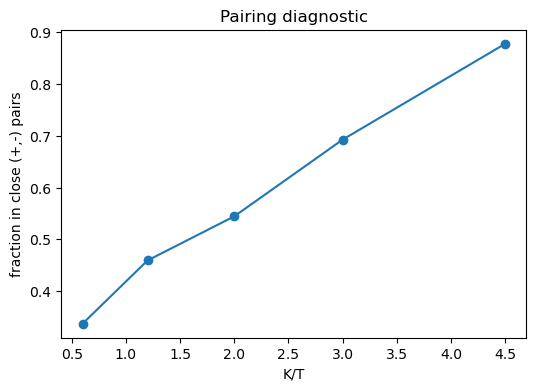

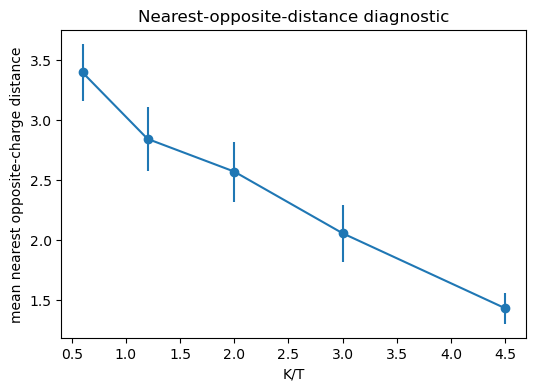

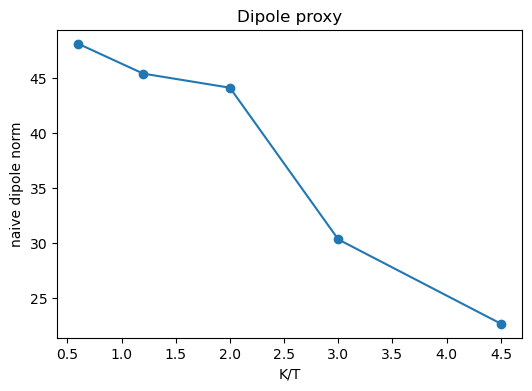

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ks, pair_fracs, marker="o")
ax.set_xlabel("K/T")
ax.set_ylabel("fraction in close (+,-) pairs")
ax.set_title("Pairing diagnostic")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(Ks, mean_nn, yerr=std_nn, marker="o")
ax.set_xlabel("K/T")
ax.set_ylabel("mean nearest opposite-charge distance")
ax.set_title("Nearest-opposite-distance diagnostic")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ks, dipoles, marker="o")
ax.set_xlabel("K/T")
ax.set_ylabel("naive dipole norm")
ax.set_title("Dipole proxy")
plt.show()


## Show one saved snapshot inline

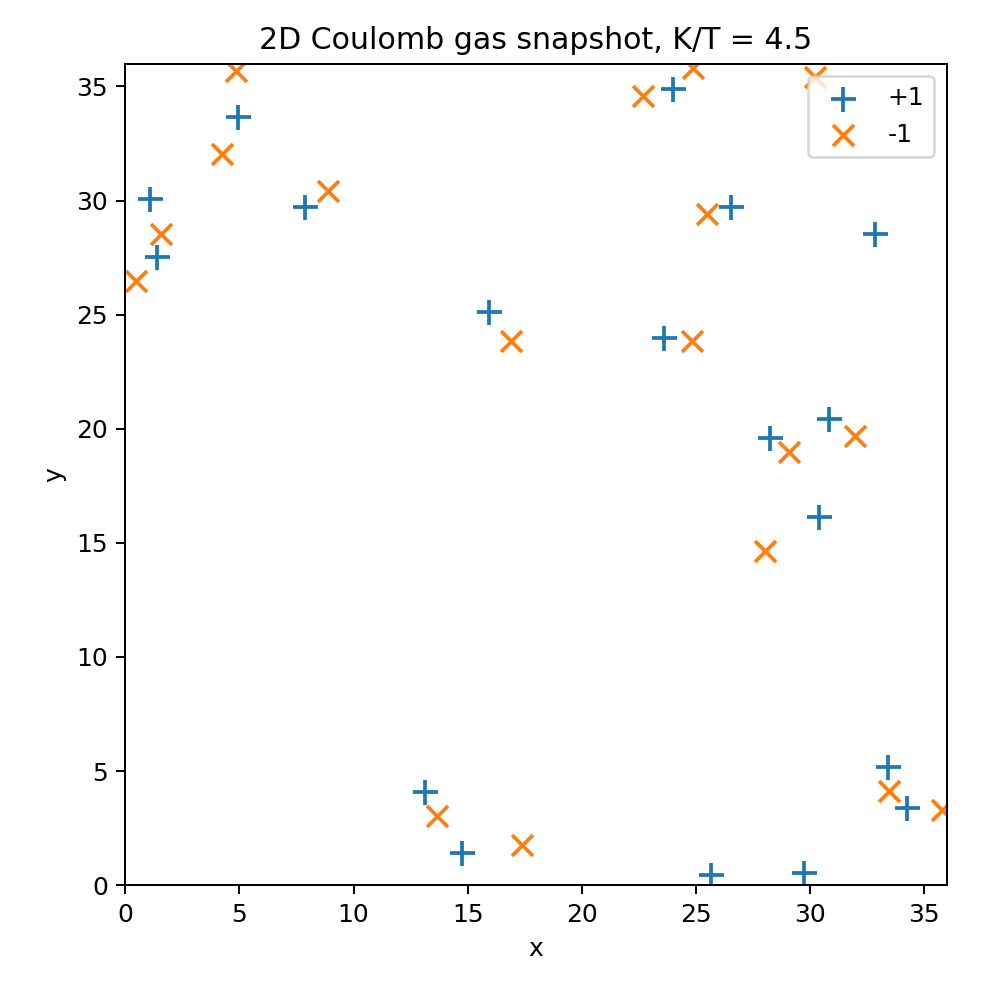

In [12]:
from IPython.display import Image, display

example_path = outdir / f"snapshot_K_{K_over_T_values[-1]:.2f}.png"
display(Image(filename=str(example_path)))


## Next upgrades if you want to get closer to the papers

1. **Grand-canonical moves**: create/annihilate neutral \((+,-)\) pairs instead of fixing particle number.
2. **Better long-range treatment**: 2D Ewald or sphere geometry.
3. **Cluster / pair moves**: important in the strongly bound regime.
4. **Dielectric observable**: estimate a proper dielectric response or inverse dielectric constant, since that is what the phase-diagram papers actually use. 
5. **Density scan**: the literature phase diagram depends on both temperature/coupling and density, not just one fixed density.

If you want, the next step should be a cleaner **grand-canonical notebook** that tries to mimic the dielectric-gas / conducting-liquid story more closely.


## Important physics note

This modified notebook now matches the uploaded periodic-boundary-condition derivation in the sense that the interaction is a **2D-periodic Ewald sum of a \(1/r\) Coulomb kernel** with the \(G=0\) term removed and the PDF self-energy available for reporting.

However, the classic 2D Coulomb gas used for BKT physics usually uses a **logarithmic** interaction, because the Green's function of the 2D Laplacian is \(-\log r\), not \(1/r\). Therefore:

- use `interaction_mode = "ewald_1_over_r"` to match `electrons_in_pbc.pdf`;
- use `interaction_mode = "log_minimum_image"` to reproduce the old BKT-style toy simulation.

Do not mix the two when interpreting phase behavior.

